# 0 - Imports

In these first sections we will cover installations of all libraries taking into account the platform in which this notebook will be executed

## 0.1 Colab Setting

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !pip install ftfy regex tqdm
    !pip install git+https://github.com/openai/CLIP.git
    !pip install torchmetrics
    !pip3 install torch torchvision torchaudio
    !pip install -U ultralytics
else:
    print("Not running on Google Colab")


Not running on Google Colab


In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !mkdir dataset
    !gdown 1A_ezza3Bj3OJv8wgTyIsLynNqqztRwl4
    !ls
    !mv Uploaded_refcocog.tar.gz ./dataset/
    !ls dataset
else:
    print("Not running on Google Colab")


Not running on Google Colab


## 0.2 Imports

In [3]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random
import heapq
from __future__ import  absolute_import
import os
from collections import namedtuple
import time

from typing import Any, Optional

import torch
from torch import nn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.ops import roi_align
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm, trange
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw
from tabulate import tabulate

from ipywidgets import FloatProgress
import math
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert
from torchvision.ops import nms
from torchvision.ops import RoIPool

## 0.3 Tensorboard and Metrics

In [4]:
%load_ext tensorboard

In [5]:
if torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

CUDA backend is available.


In [6]:
log_dir = 'logs'

# 1 - Utils

## 1.1 Helper Functions and Cells

The `plot_images` function displays a list of images in a grid. Used only for displaying purposes

In [7]:
def plot_images(images):
    
    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

In [8]:
def draw_bboxes(image_path, bbox, gt, confidence):
    image = cv2.imread(image_path)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), other_bbox_color, 2)
    cv2.putText(image, 'Confidence' + str(confidence), (int(bbox[0]), int(bbox[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, other_bbox_color, 2)
    color = max_bbox_color
    cv2.rectangle(image, (int(gt[0]), int(gt[1])) ,(int(gt[2]), int(gt[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image_rgb

In [9]:
def plot_images_case(cases):
    images = []

    for i, case in enumerate(cases):
        image_path = os.path.join('', case["path"])
        ground_truth=case["ground_truth"]
        candidate=case["candidate"]
        confidence= case['confidence']
        images.append(draw_bboxes(image_path,candidate,ground_truth,confidence))

    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

'draw_bboxes' is used to confront the extracted `bbox` with the relative `ground_truth`

function to compute the Intersection Over Union of two different bboxes

In [10]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

In [11]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [12]:
with open("../refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("../refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [13]:
def tonumpy(data):
    if isinstance(data, np.ndarray):
        return data
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy()


def totensor(data, cuda=False):
    if isinstance(data, np.ndarray):
        tensor = torch.from_numpy(data)
    if isinstance(data, torch.Tensor):
        tensor = data.detach()
    if cuda:
        tensor = tensor.cuda()
    return tensor


def scalar(data):
    if isinstance(data, np.ndarray):
        return data.reshape(1)[0]
    if isinstance(data, torch.Tensor):
        return data.item()

## 1.2 MetricMeter

Class to help track down examples duting runs

In [14]:
# MetricMeter (Unchanged from before, ready to track all metrics)
class MetricMeter:
    def __init__(self, name="Default", threshold=0.5, log_dir='./logs/default_run', save_dir='./metrics'):
        self.name = name
        self.threshold = threshold
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.reset()
        self.writer = SummaryWriter(log_dir=log_dir)

        # Best/Worst cases using heaps for efficient tracking
        self.best_cases_iou = []
        self.worst_cases_iou = []
        self.best_cases_sim = []
        self.worst_cases_sim = []

    def reset(self):
        self.count = 0
        self.iou = 0
        self.epoch = 0
        self.correct_bboxes = 0
        self.semantic = 0
        self.metrics = []

    def _update_heap(self, heap, item, max_size, reverse=False):
        """Update a min or max heap with a new item."""
        if len(heap) < max_size:
            heapq.heappush(heap, (item['iou'] if not reverse else -item['iou'], item))
        else:
            if (item['iou'] > heap[0][0]) if not reverse else (item['iou'] < -heap[0][0]):
                heapq.heappushpop(heap, (item['iou'] if not reverse else -item['iou'], item))

    def update(self, iou, confidence, filename, bbox_e, bbox_gt):
        try:
            self.count += 1
            self.iou += iou
            if iou >= self.threshold:
                self.correct_bboxes += 1
            self.semantic += confidence

            item = {
                'iou': iou,
                'confidence': confidence,
                'ground_truth': bbox_gt,
                'candidate': bbox_e,
                'path': filename
            }

            # Update heaps
            self._update_heap(self.best_cases_iou, item, max_size=5)
            self._update_heap(self.worst_cases_iou, item, max_size=5, reverse=True)
            self._update_heap(self.best_cases_sim, item, max_size=5)
            self._update_heap(self.worst_cases_sim, item, max_size=5, reverse=True)
        except Exception as e:
            print(e)

    def new_epoch(self, tag):
        self.epoch += 1

        # Log epoch metrics
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.epoch)
        self.writer.add_scalar('Grounding Accuracy', self.correct_bboxes / self.count, self.epoch)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.epoch)

        # Serialize tensors to JSON-friendly formats
        def serialize_case(case):
            return {
                'iou': float(case['iou']),
                'confidence': float(case['confidence']),
                'ground_truth': case['ground_truth'].tolist() if isinstance(case['ground_truth'], torch.Tensor) else case['ground_truth'],
                'candidate': case['candidate'].tolist() if isinstance(case['candidate'], torch.Tensor) else case['candidate'],
                'path': case['path']
            }

        epoch_data = {
            'epoch': self.epoch,
            'metrics': {
                'localization_accuracy': self.iou / self.count,
                'grounding_accuracy': self.correct_bboxes / self.count,
                'semantic_similarity': self.semantic / self.count
            },
            'best_cases_iou': [serialize_case(item[1]) for item in sorted(self.best_cases_iou, key=lambda x: x[0], reverse=True)],
            'worst_cases_iou': [serialize_case(item[1]) for item in sorted(self.worst_cases_iou, key=lambda x: x[0])],
            'best_cases_sim': [serialize_case(item[1]) for item in sorted(self.best_cases_sim, key=lambda x: x[0], reverse=True)],
            'worst_cases_sim': [serialize_case(item[1]) for item in sorted(self.worst_cases_sim, key=lambda x: x[0])]
        }

        with open(os.path.join(self.save_dir, f'metrics_epoch_{self.epoch}_{tag}.pkl'), 'wb') as f:
            pickle.dump(epoch_data, f)


        self.reset()

# 2 - Data Preparation and Augmentation

In [15]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3).to(device)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3).to(device)
    image = image.to(device)
    denormalized_image = image * std + mean
    return denormalized_image

class Denormalize:
    def __init__(self):
        clip_mean = [0.48145466, 0.4578275, 0.40821073]
        clip_std = [0.26862954, 0.26130258, 0.27577711]
        self.mean = torch.tensor(clip_mean).reshape(-1, 1, 1)  # Adjust shape to (H, W, C)
        self.std = torch.tensor(clip_std).reshape(-1, 1, 1)

    def __call__(self, tensor):
        # Denormalize the image tensor
        denormalized_tensor = tensor * self.std + self.mean
        return denormalized_tensor

In [16]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [17]:
class DataAugmentation():
# This class is used to perform tranformation in order to have augmented data

    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            # since we do another manipulation we compute again the normalization
            # of the image even tho clip does it before
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def Hflip(self,img,bbox):
        # flip horizontally both image and bbox
        #img = v2.functional.hflip(img)
        cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

        # flip the y coordinate
        transform = v2.Compose([
            v2.PILToTensor(),
            #Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

        bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
        return img, bbox

    def random_augmentation(self,img,bbox):
        # Randomly choose a transformation to be applied to the image
        img = img.to("cpu")
        n = random.randint(0, 4)
        if n == 0:
            return DataAugmentation.blur(self,img,bbox)
        elif n == 1:
            return DataAugmentation.Hflip(self,img,bbox)
        elif n == 2:
            return DataAugmentation.grayscale(self,img,bbox)
        elif n == 3:
            return DataAugmentation.colorrand(self,img,bbox)
        else:
            return DataAugmentation.Hflip(self,img,bbox)

In [18]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [19]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name':
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x
                - y
                - width
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 8000):

        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        #self.images = []
        self.raws = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()
        self.split = split


        temp = 0
        for elem in [d for d in refs if d["split"]==split]:

            # Retrieve Single image
            file_name = os.path.join("../refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            #image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')

            # Get all texts related to the picture
            sentences = elem['sentences']

            self.raws.append(sentences[0]['raw'])
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            #self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if (temp > count):
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        
        raw = self.raws[idx]
        text = self.texts[idx]
        #images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        original_height = image.size[1]
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        if(self.split=='train'):
            image, gt = self.AUG.random_augmentation(image,gt)
        processed_height = image.size(-2)



        scale = processed_height / original_height

        #image = self.clip_preprocess(image).to(device)
        return raw, text, gt, cls, filename, image, scale

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [20]:
count = 16 * 4

In [21]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, count=count, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=8)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=count, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=8)
len_test = len(dataset_test)
print(f"Numero esempi in test = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=7, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=8)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 65
----------------------Processing test split-----------------------------
Numero esempi in test = 65
----------------------Processing eval split-----------------------------
Numero esempi in eval = 8
------------------------------------------------------------------------


# 4 - External Attention

In [22]:
MOMENTUM = 0.1 #Default should be 3e-4

class ConvBNReLU(nn.Module):
    '''Module for the Conv-BN-ReLU tuple.'''

    def __init__(self, c_in, c_out, kernel_size, stride, padding, dilation):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(
                c_in, c_out, kernel_size=kernel_size, stride=stride, 
                padding=padding, dilation=dilation, bias=False)
        self.bn = nn.SyncBatchNorm(c_out, momentum=MOMENTUM)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [23]:
class External_attention(nn.Module):

    '''
    Arguments:
        c (int): The input and output channel number.
    '''
    def __init__(self, c):
        super(External_attention, self).__init__()
        
        self.conv1 = nn.Conv2d(c, c, 1) #Convolution to linear layer
        self.al4 = 0
        self.k = 64
        self.fc0 = ConvBNReLU(2048, 512, 3, 1, 1, 1)
        self.linear_0 = nn.Conv1d(c, self.k, 1, bias=False)
        self.norm_layer = nn.SyncBatchNorm(c, momentum=MOMENTUM)
        self.linear_1 = nn.Conv1d(self.k, c, 1, bias=False)
        self.linear_1.weight.data = self.linear_0.weight.data.permute(1, 0, 2)        
        self.fc1 = nn.Sequential(
            ConvBNReLU(512, 256, 3, 1, 1, 1),
            nn.Dropout2d(p=0.1))
        self.conv2 = nn.Sequential(
            nn.Conv2d(c, c, 1, bias=False),
            self.norm_layer)    
        self.fc2 = nn.Conv2d(256, 80, 1)   
        self.final_linear = nn.Sequential(
            nn.Linear(3920, 1024)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d): # Kaiming Initialiaztion
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.Conv1d):# He Initialization
                n = m.kernel_size[0] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, _BatchNorm): # BatchNorm Initialization all setted to 1
                m.weight.data.fill_(1)
                if m.bias is not None:
                    m.bias.data.zero_()

    # We need to compute the tensor one example by another in order for the memory units to 
    # grasp possible correlations between the different examples
    def process_features(self, tensor, shift=1):
        cycled_tensor = torch.roll(tensor, shifts=shift, dims=0)
        outputs = []
        
        for i in range(cycled_tensor.shape[0]):
            # Extract each slice along the first dimension
            tensor_slice = cycled_tensor[i]
            
            # Pass the slice through the model's forward method
            output = self.forward(tensor_slice.unsqueeze(0))  # Unsqueeze to add the batch dimension back
            
            # Store the output
            outputs.append(output)
        
        # Combine the outputs back into a single tensor if needed
        combined_output = torch.cat(outputs, dim=0)
        
        return combined_output


    def forward(self, x):
        # print(x.shape)
        x = self.fc0(x)
        idn = x
        x = self.conv1(x)

        b, c, h, w = x.size()
        n = h*w
        x = x.view(b, c, n)   # b * c * n 

        attn = self.linear_0(x) # b, k, n
        attn = F.softmax(attn, dim=-1) # b, k, n

        attn = attn / (1e-9 + attn.sum(dim=1, keepdim=True)) #  # b, k, n
        x = self.linear_1(attn) # b, c, n

        x = x.view(b, c, h, w)
        x = self.conv2(x)
        x = x + idn
        x = F.relu(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = x.view(1, -1)
        # print(x.shape)
        x = self.final_linear(x)

        return x

In [24]:
from torch.cuda.amp import autocast

class ExternalYoloClip(nn.Module):
    def __init__(self, clip_model, clip_preprocess, device = 'cpu'):
        super(ExternalYoloClip, self).__init__()
        self.yolo = YOLO("yolov8n.pt")
        self.EA = External_attention(512).to(device)
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        self.processing = []
        self.similarities = []
        self.device = device

    def encode_image(self, image):
        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features
    
    def preprocess_images(self, cropped_images):
        # preprocess with CLIP each cropped PIL image(converts each image in a image
        # of size [3,224,224])
        processing = []
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            # proc = self.clip_model.encode_image(processed_img)
            processing.append(processed_img)
        preprocessed = torch.tensor(np.stack(processing))
        # preprocessed = torch.stack(processing).to(self.device) # return a single tensor
        return preprocessed


    def encode_text(self, text):
        with torch.no_grad():
            # print("HELL YEAH: ", text.shape)
            text_features = self.clip_model.encode_text(text)
        return text_features
    
    def hook_fn(self, module, input, output):
        self.al = output

    def forward(self, images, text):
        clip_model.visual.layer4.register_forward_hook(self.hook_fn) # handle to retrieve output
        
        image_features = self.encode_image(images)
        with autocast():
            image_features = self.EA.process_features(self.al)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        with autocast():
            text_features = self.encode_text(text)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        # text_features2 = text_features2 / text_features2.norm(dim=-1, keepdim=True)
        logit_scale = self.logit_scale.exp()
        # normalized featuresim
        similarity = (image_features @ text_features.t())
        
        scaled_similarity = logit_scale * similarity
        logits_per_image = scaled_similarity
        logits_per_text = scaled_similarity.t()

        return logits_per_image, logits_per_text
    
    def evaluator(self, crop_images, text, filepath):
        self.eval()
        best_score = 0
        best_bbox = None
        candidates = []
        images = []

        ex_bbox, cls = self.infer_bboxes(images)

        for bbox in self.infer_bboxes(ex_bbox):
            temp = cv2.imread(filepath)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).unsqueeze(0).to(device)
            images.append(image)
        
        li,lt = self.model(images,text)
        print(li)

    def infer_bboxes(self, image_path):
        #print(image_path)
        with torch.no_grad():
            results = self.yolo(image_path, verbose=False)
        # print(results[0])
        bboxes = results[0].boxes.xyxy
        #cls = results[0].boxes.cls
        return bboxes

    def get_candidate_crop(self, text,path):
        images = []
        texts = []
        best_score = 0
        best_bbox = None
        infered_bboxes = self.infer_bboxes(path)
        # print("\nLISTA bboxes\n")
        # for id, i in enumerate(infered_bboxes):
        #     print("bbox:", i, " posizione: ", id)
        for bbox in infered_bboxes:
            temp = cv2.imread(path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = clip_preprocess(Image.fromarray(image)).to(device)
            #print(image.shape)
            images.append(image)
        imagesa = torch.stack(images)
        texts.append(text)
        texts = torch.stack(texts)

        with torch.no_grad():
                logits_per_image, logits_per_text = model(imagesa, texts)
                matching_score = logits_per_text.cpu().numpy()[0]
                print('ids: ', matching_score)
                matching_score = np.argmax(matching_score)
                print("id best: ", matching_score)

        best_score = matching_score
        #print("list_bbox:", infered_bboxes[best_score])
        best_bbox = infered_bboxes[best_score]
        best_score +=1
        
        return best_score, best_bbox



In [25]:
model = ExternalYoloClip(clip_model= clip_model, clip_preprocess=clip_preprocess)

In [26]:
NUM_EPOCHS = 15
count = 0
iou_threshold = 0.5
loss_meter = MetricMeter(name = 'TrainingEA', threshold=iou_threshold)

running_loc_acc = 0.0
correct_bboxes = 0
overall = 0
semantic = 0
semantic_similarity = 0
running_ga = 0
sem = 0
loc_acc = 0
model = ExternalYoloClip(clip_model,clip_preprocess,device='cpu')

In [27]:
loss_meter.reset()

In [28]:
lr = 0.0001
# wd = 0.002 # best run so far
wd = 0.001
alpha = 1 # to decrease lr over time

In [29]:
cost = nn.CrossEntropyLoss()
optimizer = torch.optim.Adadelta(model.parameters(), lr=lr, weight_decay = wd)
optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)

In [30]:
def freeze_layers(model):
    for param in model.clip_model.parameters():
        param.requires_grad = False

def unfreeze_layers(model):
    for param in model.clip_model.parameters():
        param.requires_grad = True

In [31]:
def train_Pipeline(model):
    model.clip_model.train()
    model.EA.train()

def eval_Pipeline(model):
    model.clip_model.eval()
    model.EA.eval()

In [33]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
overall = 0
errors = 0
loss = 0
acc = 0

test_cumulative_accuracy = 0.0
test_cumulative_loss = 0.0
test_overall = 0
test_errors = 0

writer = SummaryWriter(log_dir="./logs/training")
train_metric_meter = MetricMeter(name="Training Metrics")
eval_metric_meter = MetricMeter(name="Evaluation Metrics")

for i in range(NUM_EPOCHS):
    loop = tqdm(dataloader_train, position=0, leave=True)
    train_Pipeline(model)

    for _, data in enumerate(loop):
        try:
            texts = data[1].squeeze(1).to(device)
            gts = data[2]
            filename = data[4]
            images = []

            for x in filename:
                temp = Image.open(x)
                image = clip_preprocess(temp).to(device)
                images.append(image)

            images = torch.stack(images)
            optimizer.zero_grad()

            # Forward pass
            li, lt = model.forward(images, texts)

            # Compute losses
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            img_loss = cost(li, ground_truth)
            desc_loss = cost(lt, ground_truth)
            loss = (img_loss + desc_loss) / 2

            # Backpropagation
            loss.backward()
            optimizer.step()

            # Update metrics
            _, predicted = li.max(dim=1)
            batch_accuracy = predicted.eq(ground_truth).sum().item() / len(images)

            train_metric_meter.update(
                iou=0,  # Placeholder for IoU (if applicable)
                confidence=batch_accuracy,
                filename="N/A",  # Filename isn't relevant for this metric
                bbox_e=None,
                bbox_gt=None
            )

            # Update loop description
            loop.set_description(f"Training Epoch {i} => Loss: {loss.item():.4f}, Accuracy: {batch_accuracy:.4f}")

        except Exception as e:
            print(f"Error processing batch: {e}")
            errors += 1

    # Log training metrics
    train_metric_meter.new_epoch('EA_TRAIN')
    writer.add_scalar("Training/Loss", loss, i)
    #writer.add_scalar("Training/Accuracy", train_metric_meter.semantic / train_metric_meter.count, i)

    

    # Evaluation Phase
    if i % 3 == 0:
        test_loop = tqdm(dataloader_test, position=0, leave=True)
        eval_Pipeline(model)

        with torch.no_grad():
            for _, data in enumerate(test_loop):
                try:
                    texts = data[1].squeeze(1).to(device)
                    gts = data[2]
                    filename = data[4]
                    images = []

                    for x in filename:
                        temp = Image.open(x)
                        image = clip_preprocess(temp).to(device)
                        images.append(image)

                    images = torch.stack(images)
                    li, lt = model.forward(images, texts)

                    # Compute losses
                    ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
                    img_loss = cost(li, ground_truth)
                    desc_loss = cost(lt, ground_truth)
                    loss = (img_loss + desc_loss) / 2

                    # Update metrics
                    _, predicted = li.max(dim=1)
                    batch_accuracy = predicted.eq(ground_truth).sum().item() / len(images)

                    eval_metric_meter.update(
                        iou=0,  # Placeholder for IoU
                        confidence=batch_accuracy,
                        filename="N/A",
                        bbox_e=None,
                        bbox_gt=None
                    )

                    # Update loop description
                    test_loop.set_description(f"Evaluation Epoch {i} => Loss: {loss.item():.4f}, Accuracy: {batch_accuracy:.4f}")

                except Exception as e:
                    print(f"Error during evaluation: {e}")
                    test_errors += 1

        # Log evaluation metrics
        eval_metric_meter.new_epoch('EA_EVAL')
        # writer.add_scalar("Evaluation/Loss", eval_metric_meter.iou / eval_metric_meter.count, i)
        # writer.add_scalar("Evaluation/Accuracy", eval_metric_meter.semantic / eval_metric_meter.count, i)

# Close the writer at the end of training
writer.close()

  0%|          | 0/9 [00:00<?, ?it/s]

/home/matea/Documents/GitHub/DL2023-Carolo-Maines/DL/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/tmp/ipykernel_99106/1897070360.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatTensor) should be the same
Error processing batch: Input type (torch.cuda.HalfTensor) and weight type (torch.FloatT

ZeroDivisionError: division by zero

In [41]:
test_loop = tqdm(dataloader_test, position=0, leave=True)
# Initialize the metric tracker
metric_tracker2 = MetricMeter(name="EA Testing", threshold=0.5)
proc = []

eval_Pipeline(model)
with torch.no_grad():
    for _, data in enumerate(test_loop):
        texts = data[1].squeeze(1).to(device)
        gts = data[2]
        filename = data[4]
        images = []

        for x in filename:
            temp = Image.open(x)
            image = clip_preprocess(temp).to(device)
            images.append(image)

        images = torch.stack(images)
        batch = len(images)
        overall += batch
        cumulative_iou = 0
        cumulative_sim = 0
        for i in range(batch):
            print()
            score, ebbox = model.get_candidate_crop(texts[i], filename[i])
            # # scores.append(score)
            # print("after get_candidate", ebbox)
            # # bboxes.append(ebbox)
            # print(ebbox)
            # print(gts[i])
            iou = compute_iou(ebbox, gts[i])
            cumulative_iou += iou
            if(iou > iou_threshold):
                #compare_candidate_bbox(filename,bbox_e, bbox_gt)
                correct_bboxes += 1
            similarity = score / 100

            # print('iou : ', iou)
            # print('similarity : ', similarity)
            # print('path : ', filename[i])
            # print('extracted bbox : ', ebbox)
            # print('ground truth : ', gts[i])

            metric_tracker2.update(iou, similarity, filename[i], ebbox, gts[i])

            loc_acc = metric_tracker2.iou / metric_tracker2.count
            ga = metric_tracker2.correct_bboxes / metric_tracker2.count
            semsim = metric_tracker2.semantic / metric_tracker2.count

            # Add visualization (if needed)
            if len(proc) < 9:
                proc.append(draw_bboxes(filename[i], ebbox, gts[i], score))
                
            cumulative_sim += score
            print("OVERALL: ", overall)
            loc_acc = cumulative_iou / overall
            ga = correct_bboxes / overall
            # semsim = cumulative_sim / overall 
        test_loop.set_description(f"Localization accuracy = {loc_acc:.4f}, Grounding Accuracy = {ga:.4f}, Semantic Similarity = {semsim:.4f}")

metric_tracker2.new_epoch('test')

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [48]:
# Load the data
with open('metrics/metrics_epoch_1_test.pkl', 'rb') as f:
    data = pickle.load(f)

# Access the metrics and other data
print(f"Epoch: {data['epoch']}")
print(f"Localization Accuracy: {data['metrics']['localization_accuracy']}")
print(f"Grounding Accuracy: {data['metrics']['grounding_accuracy']}")
print(f"Semantic Similarity: {data['metrics']['semantic_similarity']}")

# Access best and worst cases
best_cases_iou = data['best_cases_iou']
worst_cases_iou = data['worst_cases_iou']
best_cases_sim = data['best_cases_sim']
worst_cases_sim = data['worst_cases_sim']

print("Best IoU Cases:")
for case in best_cases_iou:
    print(case)

print("Worst IoU Cases:")
for case in worst_cases_iou:
    print(case)

Epoch: 1
Localization Accuracy: 0.2902063727378845
Grounding Accuracy: 0.27692307692307694
Semantic Similarity: 0.0356923076923077
Best IoU Cases:
{'iou': 0.9843471050262451, 'confidence': 0.01, 'ground_truth': [305.6499938964844, 213.0399932861328, 639.280029296875, 411.07000732421875], 'candidate': [304.27825927734375, 214.41033935546875, 638.8009643554688, 407.2635498046875], 'path': '../refcocog/images/COCO_train2014_000000410969.jpg'}
{'iou': 0.9812058806419373, 'confidence': 0.03, 'ground_truth': [267.4700012207031, 111.87999725341797, 448.55999755859375, 402.8399963378906], 'candidate': [267.6976318359375, 118.70208740234375, 448.06890869140625, 400.24664306640625], 'path': '../refcocog/images/COCO_train2014_000000564676.jpg'}
{'iou': 0.98066246509552, 'confidence': 0.02, 'ground_truth': [182.85000610351562, 191.92999267578125, 282.8800048828125, 347.6199951171875], 'candidate': [183.42446899414062, 192.69964599609375, 285.5130920410156, 345.1824951171875], 'path': '../refcocog/

In [49]:
# Function to display a table of metrics
def display_metrics(epoch, loc_acc, ga, semsim):
    metrics = {
        "Metric": ["Localization Accuracy", "Grounding Accuracy", "Semantic Similarity"],
        "Value": [loc_acc, ga, semsim]
    }
    df_metrics = pd.DataFrame(metrics)
    print(f"\nEpoch: {epoch}\n")
    print(tabulate(df_metrics, headers="keys", tablefmt="pretty"))

# Function to display best and worst IoU cases as a table
def display_cases_table(cases, title):
    cases_data = []
    for case in cases:
        cases_data.append({
            "IoU": case["iou"],
            "Confidence": case["confidence"],
            "Image Path": case["path"],
            "Ground Truth": case["ground_truth"],
            "Candidate": case["candidate"]
        })
    df_cases = pd.DataFrame(cases_data)
    print(f"\n{title}\n")
    print(tabulate(df_cases, headers="keys", tablefmt="pretty"))

# Function to plot images with bounding boxes
def plot_image_with_boxes(image_path, ground_truth, candidate, title):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    draw.rectangle(ground_truth, outline="green", width=3)
    draw.rectangle(candidate, outline="red", width=3)
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Main function to display all information
def display_all_info(epoch, loc_acc, ga, semsim, best_cases, worst_cases, base_dir="."):
    # Display general metrics
    display_metrics(epoch, loc_acc, ga, semsim)
    
    # Display best IoU cases
    display_cases_table(best_cases, "Best IoU Cases")
    print("\nVisualizing Best IoU Cases:")

    plot_images_case(best_cases)
    
    # Display worst IoU cases
    display_cases_table(worst_cases, "Worst IoU Cases")
    print("\nVisualizing Worst IoU Cases:")
    plot_images_case(worst_cases)

In [50]:
best_cases_iou = data['best_cases_iou']
worst_cases_iou = data['worst_cases_iou']
best_cases_sim = data['best_cases_sim']
worst_cases_sim = data['worst_cases_sim']


Epoch: 1

+---+-----------------------+---------------------+
|   |        Metric         |        Value        |
+---+-----------------------+---------------------+
| 0 | Localization Accuracy | 0.2902063727378845  |
| 1 |  Grounding Accuracy   | 0.27692307692307694 |
| 2 |  Semantic Similarity  | 0.0356923076923077  |
+---+-----------------------+---------------------+

Best IoU Cases

+---+--------------------+------------+----------------------------------------------------+--------------------------------------------------------------------------------+---------------------------------------------------------------------------------+
|   |        IoU         | Confidence |                     Image Path                     |                                  Ground Truth                                  |                                    Candidate                                    |
+---+--------------------+------------+----------------------------------------------------+----

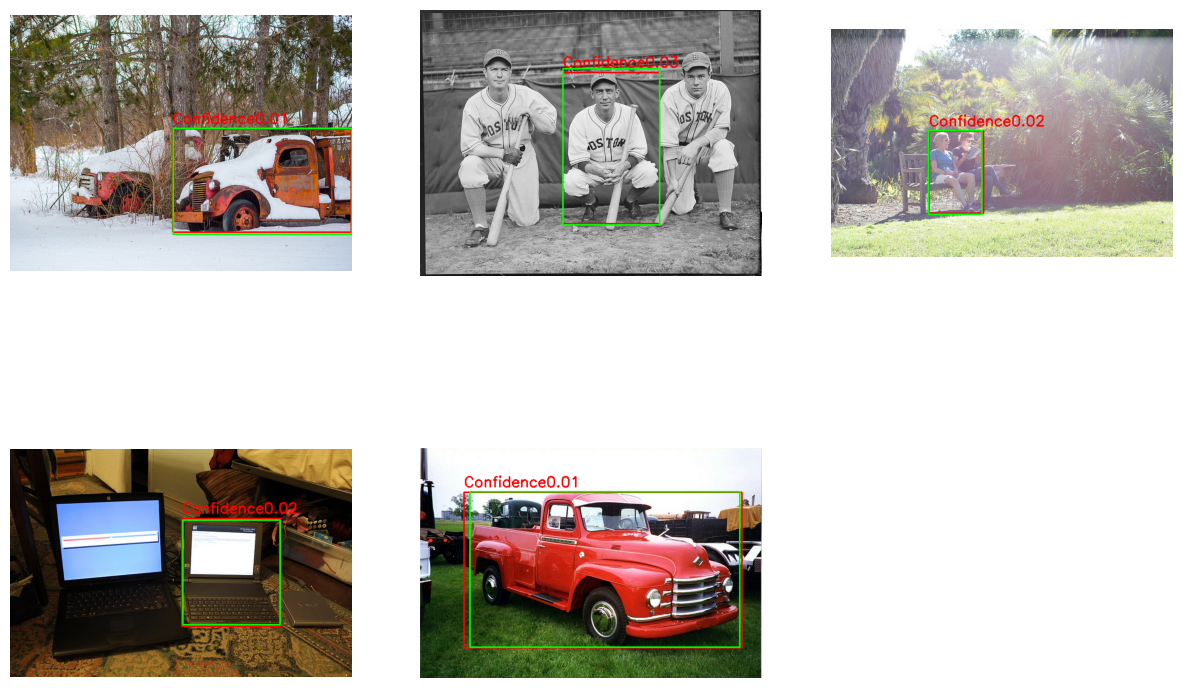


Worst IoU Cases

+---+-----+------------+----------------------------------------------------+--------------------------------------------------------------------------------+---------------------------------------------------------------------------------+
|   | IoU | Confidence |                     Image Path                     |                                  Ground Truth                                  |                                    Candidate                                    |
+---+-----+------------+----------------------------------------------------+--------------------------------------------------------------------------------+---------------------------------------------------------------------------------+
| 0 | 0.0 |    0.07    | ../refcocog/images/COCO_train2014_000000416286.jpg | [118.20999908447266, 66.0999984741211, 313.1199951171875, 179.11000061035156]  |  [341.1063232421875, 1.0598063468933105, 499.8985290527344, 55.63066101074219]  |
| 1 | 0.0 |    0.0

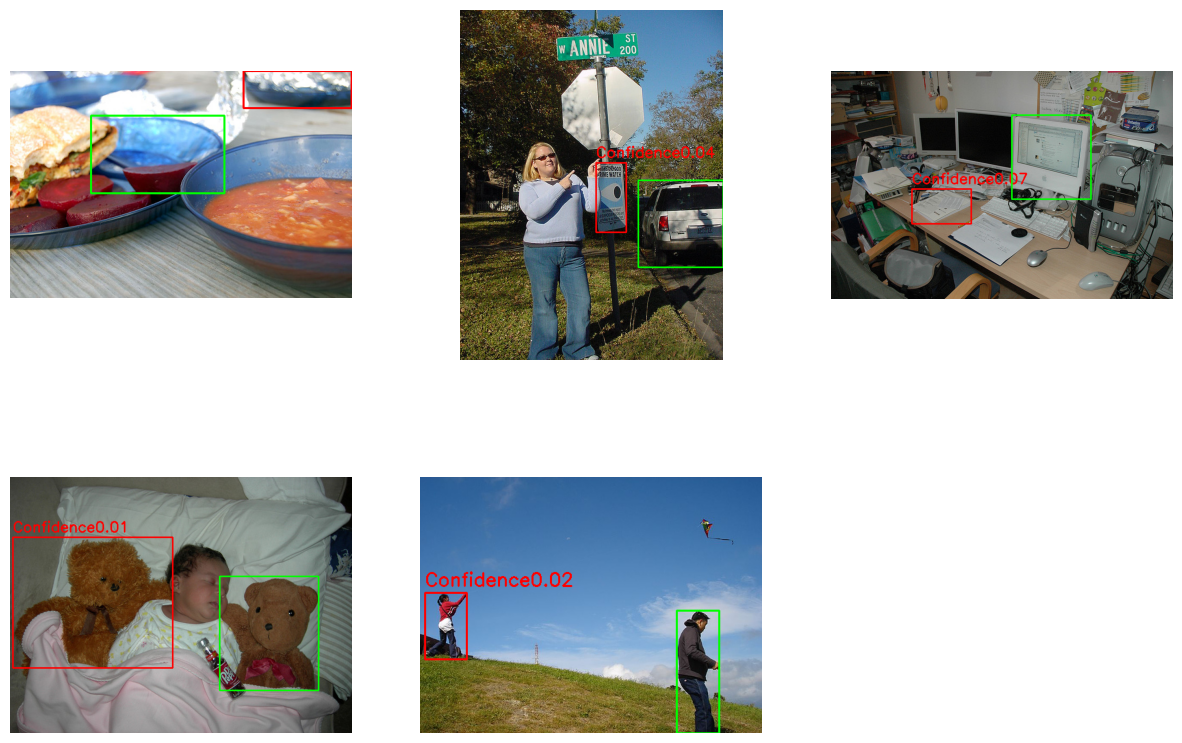

In [51]:
display_all_info(
    epoch=data['epoch'],
    loc_acc=data['metrics']['localization_accuracy'],
    ga=data['metrics']['grounding_accuracy'],
    semsim=data['metrics']['semantic_similarity'],
    best_cases=data['best_cases_iou'],
    worst_cases=data['worst_cases_iou'],
    base_dir="./refcocog"
)